# Speech Act Classification Baseline (Issue #39)

DailyDialogでSpeech Act分類(inform/question/directive/commissive)のbaselineをNaive Bayes / Logistic Regressionで作り、比較する。

予習ノート: `docs/speech-act-baseline-primer.md`

In [1]:
import sys
sys.path.insert(0, '..')
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix
from src.ml.train_speech_act import (
    load_speech_act_data, train_naive_bayes, train_logistic_regression, evaluate,
)


## 1. データロード & 探索

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = load_speech_act_data()
print(f'train={len(X_train)} val={len(X_val)} test={len(X_test)}')


train=87170 val=8069 test=7740


Counter({'inform': 39873, 'question': 24974, 'directive': 14242, 'commissive': 8081})


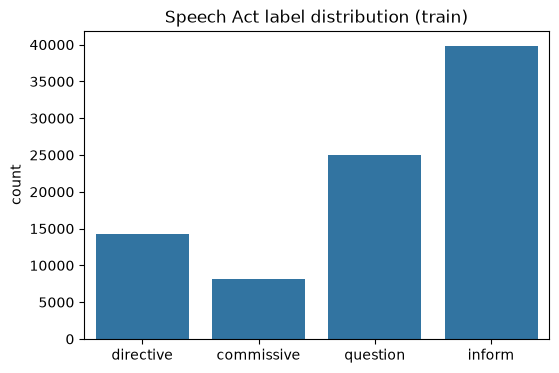

In [3]:
# ラベル分布
train_counts = Counter(y_train)
print(train_counts)
plt.figure(figsize=(6, 4))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))
plt.title('Speech Act label distribution (train)')
plt.ylabel('count')
plt.show()


**観察**: inform(情報提供)が最多(train全体の約46%)、commissive(申し出・約束)が最少(約9%)で、5倍程度の偏りがある。DailyDialogは日常会話ドメインなので、雑談的な「情報を伝える」発話が多く、「将来の行為にコミットする」発話が相対的に少ないのは自然。感情ラベルほどの極端な偏りではないが、無視できる差でもない(Logistic Regression側で`class_weight="balanced"`を使う理由)。

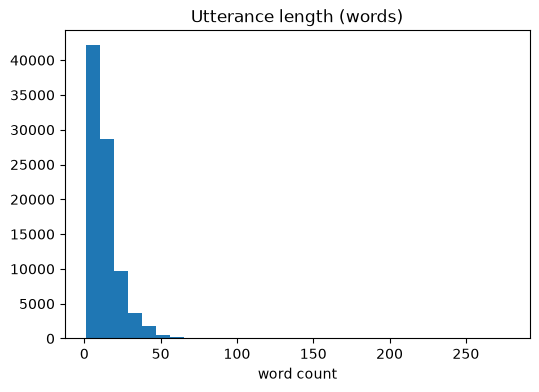

median length: 11


In [4]:
# 発話長の分布
lengths = [len(x.split()) for x in X_train]
plt.figure(figsize=(6, 4))
plt.hist(lengths, bins=30)
plt.title('Utterance length (words)')
plt.xlabel('word count')
plt.show()
print('median length:', sorted(lengths)[len(lengths)//2])


In [5]:
# サンプル表示
for text, label in list(zip(X_train, y_train))[:8]:
    print(f'[{label:>10}] {text.strip()}')


[ directive] Say , Jim , how about going for a few beers after dinner ?
[commissive] You know that is tempting but is really not good for our fitness .
[  question] What do you mean ? It will help us to relax .
[  question] Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ?
[  question] I guess you are right.But what shall we do ? I don't feel like sitting at home .
[ directive] I suggest a walk over to the gym where we can play singsong and meet some of our friends .
[commissive] That's a good idea . I hear Mary and Sally often go there to play pingpong.Perhaps we can make a foursome with them .
[    inform] Sounds great to me ! If they are willing , we could ask them to go dancing with us.That is excellent exercise and fun , too .


## 2. Baseline 1: Naive Bayes (TF-IDF)

In [6]:
nb_pipeline = train_naive_bayes(X_train, y_train)
nb_result = evaluate(nb_pipeline, X_test, y_test, 'Naive Bayes (TF-IDF)')


=== Naive Bayes (TF-IDF) ===
              precision    recall  f1-score   support

  commissive      0.828     0.033     0.064       718
   directive      0.796     0.367     0.502      1278
      inform      0.653     0.963     0.779      3534
    question      0.873     0.756     0.811      2210

    accuracy                          0.719      7740
   macro avg      0.788     0.530     0.539      7740
weighted avg      0.756     0.719     0.676      7740

Naive Bayes (TF-IDF) macro F1: 0.539



## 3. Baseline 2: Logistic Regression (TF-IDF)

In [7]:
lr_pipeline = train_logistic_regression(X_train, y_train)
lr_result = evaluate(lr_pipeline, X_test, y_test, 'Logistic Regression (TF-IDF)')


=== Logistic Regression (TF-IDF) ===
              precision    recall  f1-score   support

  commissive      0.416     0.607     0.493       718
   directive      0.614     0.728     0.666      1278
      inform      0.831     0.735     0.780      3534
    question      0.895     0.831     0.862      2210

    accuracy                          0.749      7740
   macro avg      0.689     0.725     0.700      7740
weighted avg      0.775     0.749     0.758      7740

Logistic Regression (TF-IDF) macro F1: 0.700



## 4. Confusion Matrix比較

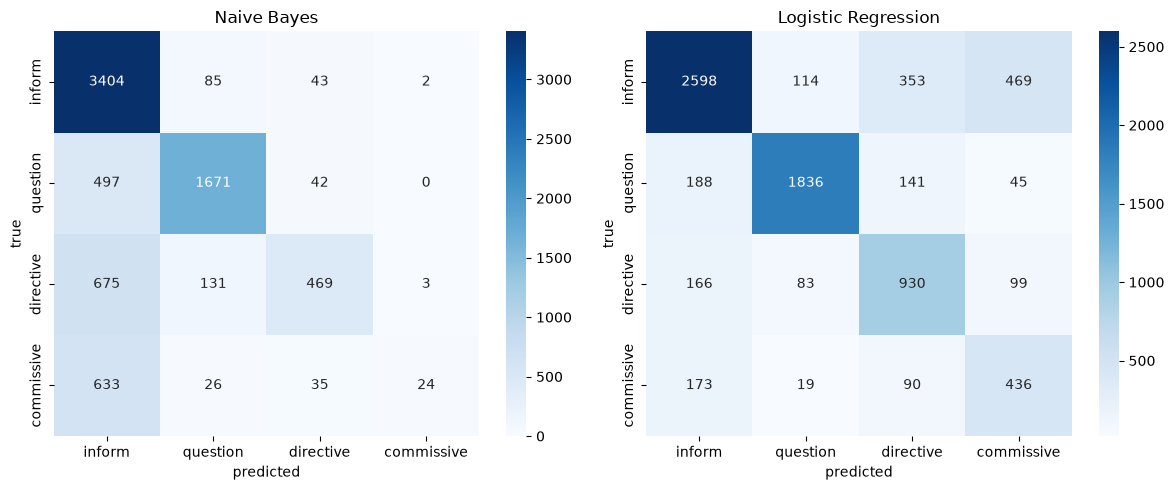

In [8]:
labels = ['inform', 'question', 'directive', 'commissive']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, result) in zip(axes, [('Naive Bayes', nb_result), ('Logistic Regression', lr_result)]):
    cm = confusion_matrix(y_test, result['y_pred'], labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, ax=ax, cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
plt.tight_layout()
plt.show()


## 5. 観察

- **Naive Bayes macro F1 = 0.539、Logistic Regression macro F1 = 0.700**。LRの方が明確に上回る。
- NBはcommissiveのrecallが**0.033**しかない(718件中ほぼ全てを別クラスに誤分類)。NBは単語の独立性を仮定するだけでクラス不均衡への補正機構を持たないため、最少数クラス(commissive, train全体の約9%)をほぼ無視してinform/questionに引きずられる。
- LRは`class_weight="balanced"`のおかげでcommissiveのrecallが**0.607**まで改善するが、代わりにprecisionが下がる(0.416)。「見逃しは減るが、誤検出は増える」というトレードオフが数字に出ている。
- Confusion matrixを見ると、**directiveとcommissiveの混同**が両モデルで目立つ。「明日までに送ります」(commissive)と「明日までに送ってください」(directive)のように、話者の役割(申し出る側か頼む側か)が違うだけで表層的な語彙が似ているケースがあり、TF-IDFのようなbag-of-words的特徴量では区別しにくいことの表れだと考えられる(語順・主語の情報を落としているため)。